# Projektarbeit Statistik  Alexander Leuenberger
# Zeitliche Entwicklung meines nächtlichen Ruhepulses im Jahr 2025

## 0.) Laden der Bibliotheken 


In [ ]:
%pip install pandas numpy matplotlib prophet statsmodels cmdstanpy --quiet

In [163]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
from prophet import Prophet
import logging
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
from statsmodels.graphics.tsaplots import plot_acf

## 1.) Laden der Daten 

In [168]:
candidates = [
    Path("data") / "Sleep_score.csv",
    Path("Sleep_score.csv"),
]

file_path = next((p for p in candidates if p.exists()), None)

if file_path is None:
    matches = list(Path(".").rglob("*.csv"))
    raise FileNotFoundError(
        "Sleep_score.csv nicht gefunden.\n"
        "Erwartet: ./Sleep_score.csv oder ./data/Sleep_score.csv\n"
        f"Gefundene CSV-Dateien im Projekt: {[str(m) for m in matches[:20]]}"
    )

df = pd.read_csv(file_path)

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True).dt.tz_convert("Europe/Zurich")
df = df.sort_values("timestamp").reset_index(drop=True)
df["date"] = df["timestamp"].dt.floor("D")

print("Geladen:", file_path)
df.head(5)

Geladen: Sleep_score.csv


,sleep_log_entry_id,timestamp,overall_score,composition_score,revitalization_score,duration_score,deep_sleep_in_minutes,resting_heart_rate,restlessness,date
0,44162187612,2024-01-14 09:21:00+01:00,87,NaN,87,NaN,100.0,76,0.052320,2024-01-14 00:00:00+01:00
1,44173809777,2024-01-15 08:02:00+01:00,73,NaN,73,NaN,75.0,69,0.096976,2024-01-15 00:00:00+01:00
2,44186135673,2024-01-16 09:38:30+01:00,88,NaN,88,NaN,112.0,66,0.068059,2024-01-16 00:00:00+01:00
3,44202643008,2024-01-17 10:10:30+01:00,80,NaN,80,NaN,72.0,66,0.132709,2024-01-17 00:00:00+01:00
4,44218077501,2024-01-18 10:37:30+01:00,87,NaN,87,NaN,104.0,67,0.095588,2024-01-18 00:00:00+01:00


In [21]:
time_col = "timestamp"
df[time_col] = pd.to_datetime(df[time_col])
df["date"] = df[time_col].dt.date
df = df.sort_values("date")
cols = ["date",
        "resting_heart_rate",
        "overall_score",
        "duration_score",
        "deep_sleep_in_minutes",
        "restlessness"]
df = df[cols]
df.head()

,date,resting_heart_rate,overall_score,duration_score,deep_sleep_in_minutes,restlessness
0,2024-01-14,76,87,NaN,100.0,0.052320
1,2024-01-15,69,73,NaN,75.0,0.096976
2,2024-01-16,66,88,NaN,112.0,0.068059
3,2024-01-17,66,80,NaN,72.0,0.132709
4,2024-01-18,67,87,NaN,104.0,0.095588


Die CSV-Datei enthält pro Nacht/Datum verschiedene Schlaf- und Pulsvariablen: resting_heart_rate (nächtlicher Ruhepuls), overall_score (Gesamtscore), duration_score (Schlafdauer-Score), deep_sleep_in_minutes (Tiefschlaf in Minuten) und restlessness (Unruhe). Für die Forschungsfrage bzw. Hypothesen verwenden wir primär den nächtlichen Ruhepuls (resting_heart_rate) als Zielvariable.


## 2.) Explorative Datenanalyse 

In [94]:
df_2025 = df[pd.to_datetime(df["date"]).dt.year == 2025].copy()

print("Anzahl Nächte:", df_2025["date"].nunique())
print("Zeitraum von", df_2025["date"].min(), "bis", df_2025["date"].max())

print(df_2025[["resting_heart_rate",
               "overall_score",
               "deep_sleep_in_minutes"]].describe())

print("\nAnzahl fehlender Werte pro Spalte:")
print(df_2025.isna().sum())

Anzahl Nächte: 293
Zeitraum von 2025-01-14 00:00:00+01:00 bis 2025-12-13 00:00:00+01:00
       resting_heart_rate  overall_score  deep_sleep_in_minutes
count          296.000000     296.000000             293.000000
mean            68.780405      75.182432              65.986348
std              2.957740       8.181034              29.413208
min             60.000000      49.000000               1.000000
25%             67.000000      70.000000              47.000000
50%             69.000000      76.000000              64.000000
75%             71.000000      81.000000              85.000000
max             77.000000      92.000000             161.000000

Anzahl fehlender Werte pro Spalte:
sleep_log_entry_id         0
timestamp                  0
overall_score              0
composition_score        296
revitalization_score       0
duration_score           296
deep_sleep_in_minutes      3
resting_heart_rate         0
restlessness               0
date                       0
dtype: int

Die Zeitreihe umfasst insgesamt 293 Nächte im Zeitraum von 2025-01-14 bis 2025-12-13. Für den nächtlichen Ruhepuls (resting_heart_rate) liegen praktisch vollständige Daten vor, mit einem Mittelwert von ca. 68.8 bpm und einer Standardabweichung von ca. 3.0 bpm (Minimum 60, Maximum 77).

Als ersten Überblick plotten wir den nächtlichen Ruhepuls als Zeitreihe. Zusätzlich berechnen wir einen zentrierten 7-Tage-Mittelwert, um kurzfristiges Rauschen zu glätten und den Verlauf über das Jahr besser sichtbar zu machen.

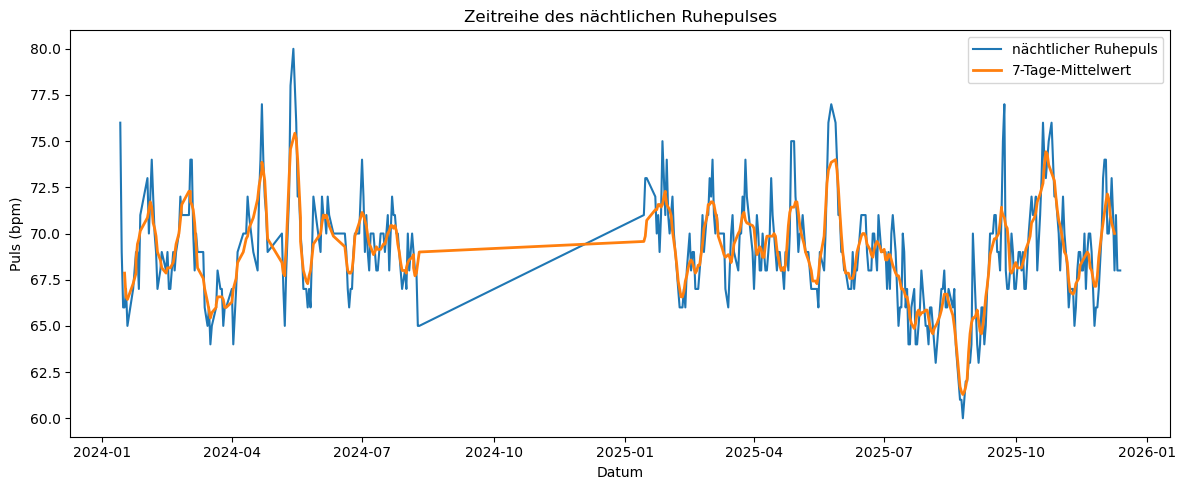

In [23]:
ts = df.set_index(pd.to_datetime(df["date"]))
ts["rhr_roll7"] = ts["resting_heart_rate"].rolling(window=7, center=True).mean()

plt.figure(figsize=(12, 5))
plt.plot(ts.index, ts["resting_heart_rate"], label="nächtlicher Ruhepuls")
plt.plot(ts.index, ts["rhr_roll7"], linewidth=2, label="7-Tage-Mittelwert")

plt.title("Zeitreihe des nächtlichen Ruhepulses")
plt.xlabel("Datum")
plt.ylabel("Puls (bpm)")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation: Die blaue Linie zeigt die täglichen Schwankungen des Ruhepulses, die orange Linie den geglätteten Verlauf. Insgesamt ist ein langsamer Verlauf über das Jahr erkennbar (längerfristige Hoch-/Tiefphasen), während einzelne Nächte deutlich davon abweichen. Auffällig ist zudem eine längere gerade Verbindung im Plot. Das weist darauf hin, dass in diesem Zeitraum Daten fehlen. Wir benötigen aber ja nur die Daten für das Jahr 2025, weshalb ist das für uns nicht so Schlimm.

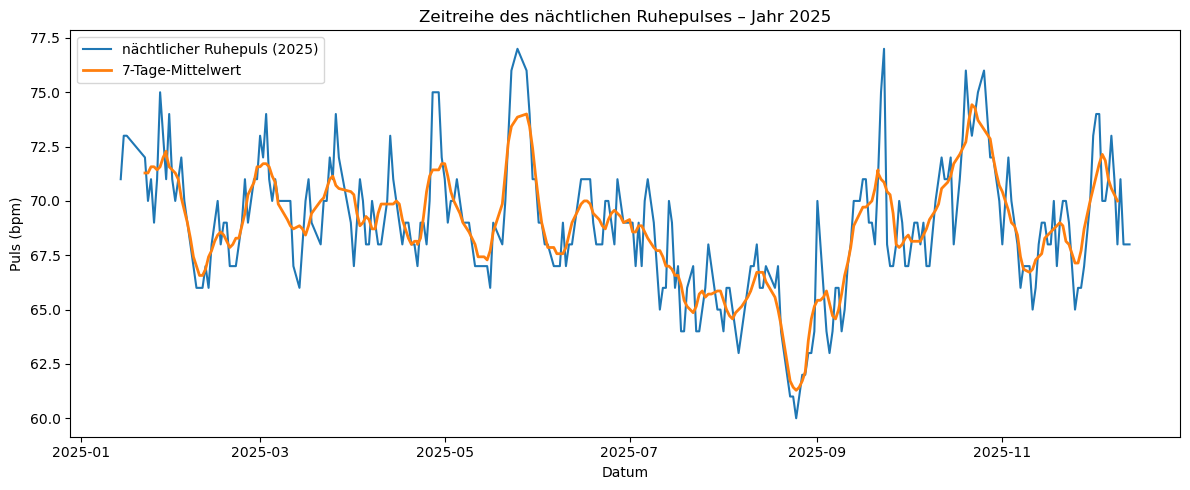

In [95]:
mask_2025 = pd.to_datetime(df["date"]).dt.year == 2025
df_2025 = df[mask_2025].copy()

ts = df_2025.set_index(pd.to_datetime(df_2025["date"]))
ts["rhr_roll7"] = ts["resting_heart_rate"].rolling(window=7, center=True).mean()

plt.figure(figsize=(12, 5))
plt.plot(ts.index, ts["resting_heart_rate"], label="nächtlicher Ruhepuls (2025)")
plt.plot(ts.index, ts["rhr_roll7"], linewidth=2, label="7-Tage-Mittelwert")
plt.title("Zeitreihe des nächtlichen Ruhepulses – Jahr 2025")
plt.xlabel("Datum")
plt.ylabel("Puls (bpm)")
plt.legend()
plt.tight_layout()
plt.show()

Interpretation: Die Zeitreihe schwankt von Nacht zu Nacht deutlich, was normal ist. Der 7-Tage-Mittelwert zeigt aber einen klareren Verlauf: Bis in den Sommer sinkt der Ruhepuls tendenziell ab (Tiefpunkt etwa August/September), danach steigt er Richtung Herbst/Winter wieder an. Einzelne Nächte liegen deutlich über oder unter dem Durchschnitt, was auf kurzfristige Einflüsse wie Stress, Krankheit, Schlafqualität oder Training hinweisen kann.

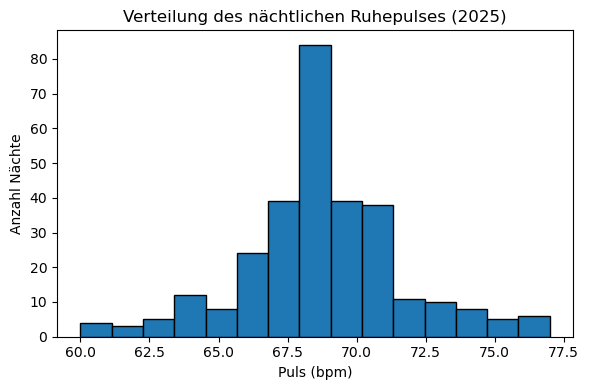

In [97]:
df["date"] = pd.to_datetime(df["date"])
df_2025 = df[df["date"].dt.year == 2025].copy()

plt.figure(figsize=(6, 4))
plt.hist(df_2025["resting_heart_rate"], bins=15, edgecolor="black")
plt.title("Verteilung des nächtlichen Ruhepulses (2025)")
plt.xlabel("Puls (bpm)")
plt.ylabel("Anzahl Nächte")
plt.tight_layout()
plt.show()

Interpretation: Für 2025 ist die Verteilung klar um etwa 68–70 bpm konzentriert (die meisten Nächte liegen in diesem Bereich). Sehr tiefe Werte um 60–63 bpm kommen nur selten vor, und auch hohe Werte über ca. 73 bpm sind eher selten. Insgesamt wirkt die Verteilung leicht rechtsschief, weil es einige wenige Nächte mit höherem Ruhepuls bis etwa 77 bpm gibt, aber keine extremen Ausreisser.

<Figure size 800x400 with 0 Axes>

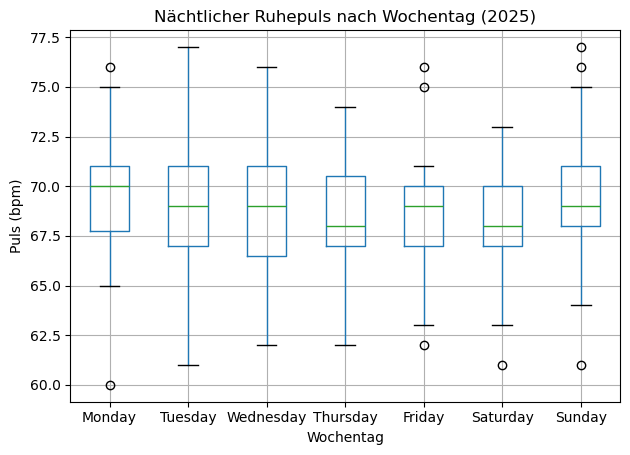

In [98]:
df["date"] = pd.to_datetime(df["date"])
df_2025 = df[df["date"].dt.year == 2025].copy()

df_2025["weekday"] = df_2025["date"].dt.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
                 "Friday", "Saturday", "Sunday"]
df_2025["weekday"] = pd.Categorical(df_2025["weekday"],
                                    categories=weekday_order,
                                    ordered=True)

plt.figure(figsize=(8, 4))
df_2025.boxplot(column="resting_heart_rate", by="weekday")
plt.suptitle("")
plt.title("Nächtlicher Ruhepuls nach Wochentag (2025)")
plt.xlabel("Wochentag")
plt.ylabel("Puls (bpm)")
plt.tight_layout()
plt.show()

Interpretation: Der Boxplot zeigt ein leichtes Wochenmuster. Die Medianwerte unterscheiden sich je nach Wochentag nur um wenige bpm: Anfang der Woche Montag liegt der Ruhepuls tendenziell etwas höher, während Donnerstag und Samstag eher etwas tiefer liegen. Die Streuung ist an allen Wochentagen ähnlich, und einzelne Ausreisser (sehr hohe oder sehr tiefe Nächte) kommen vereinzelt vor.

C:\Users\alexl\AppData\Local\Temp\ipykernel_14356\2689858103.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df_2025.groupby(df_2025["date"].dt.to_period("M"))["resting_heart_rate"].mean()


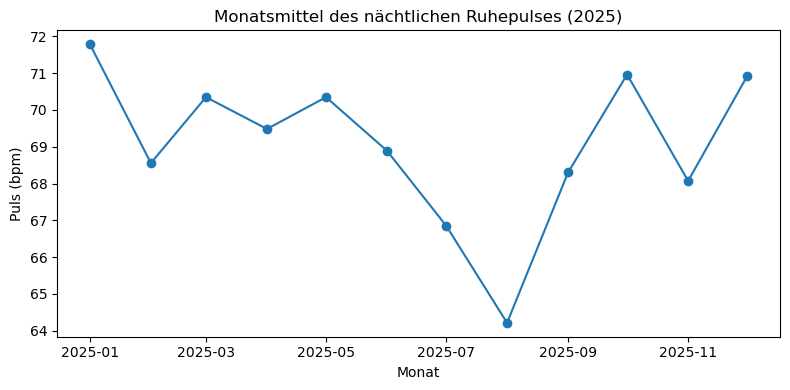

In [99]:
df["date"] = pd.to_datetime(df["date"])
df_2025 = df[df["date"].dt.year == 2025].copy()

monthly = df_2025.groupby(df_2025["date"].dt.to_period("M"))["resting_heart_rate"].mean()
monthly.index = monthly.index.to_timestamp()

plt.figure(figsize=(8, 4))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Monatsmittel des nächtlichen Ruhepulses (2025)")
plt.xlabel("Monat")
plt.ylabel("Puls (bpm)")
plt.tight_layout()
plt.show()

Interpretation: Die Monatsmittelwerte zeigen einen klaren Jahresverlauf. Zu Jahresbeginn liegt der Ruhepuls relativ hoch, sinkt dann Richtung Sommer deutlich ab (Tiefpunkt im August) und steigt ab September wieder an. Damit spricht der Verlauf für einen systematischen Trend über das Jahr (Sommer tiefer, Herbst/Winter höher).

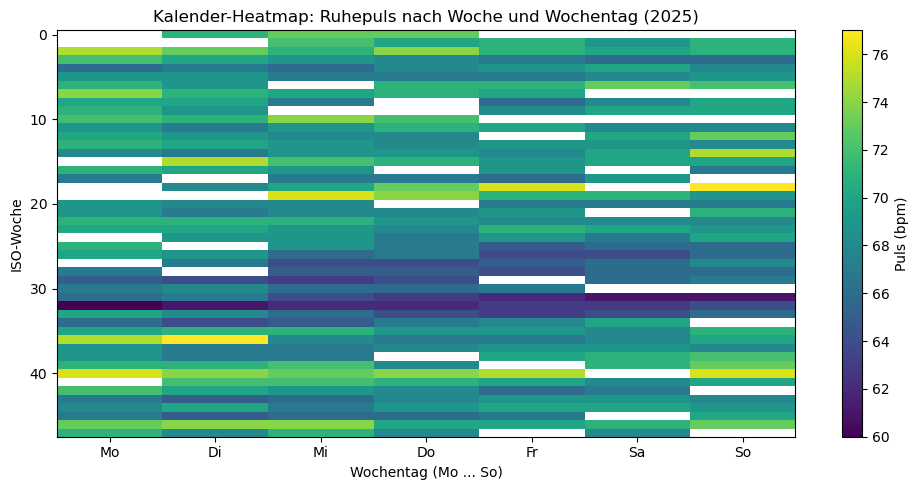

In [100]:
df["date"] = pd.to_datetime(df["date"])
df_2025 = df[df["date"].dt.year == 2025].copy()

cal = df_2025[["date", "resting_heart_rate"]].copy()
cal["week"] = cal["date"].dt.isocalendar().week.astype(int)
cal["dow"] = cal["date"].dt.weekday  # 0=Mo ... 6=So

pivot = cal.pivot_table(index="week", columns="dow", values="resting_heart_rate", aggfunc="mean")
pivot = pivot.reindex(columns=[0,1,2,3,4,5,6])

plt.figure(figsize=(10, 5))
plt.imshow(pivot.values, aspect="auto")
plt.title("Kalender-Heatmap: Ruhepuls nach Woche und Wochentag (2025)")
plt.xlabel("Wochentag (Mo ... So)")
plt.ylabel("ISO-Woche")
plt.xticks(range(7), ["Mo","Di","Mi","Do","Fr","Sa","So"])
plt.colorbar(label="Puls (bpm)")
plt.tight_layout()
plt.show()

### Als nächsten Schritt zerlegen wir die Zeitreihe des nächtlichen Ruhepulses (2025) in ihre Hauptbestandteile: Trend, Wochenmuster (Saisonalität) und Residuen. Dafür bilden wir zuerst einen täglichen Mittelwert, füllen fehlende Tage im Datumsindex auf und interpolieren diese, damit die Dekomposition mit einem 7-Tage-Zyklus (Wochenperiode) möglich ist.


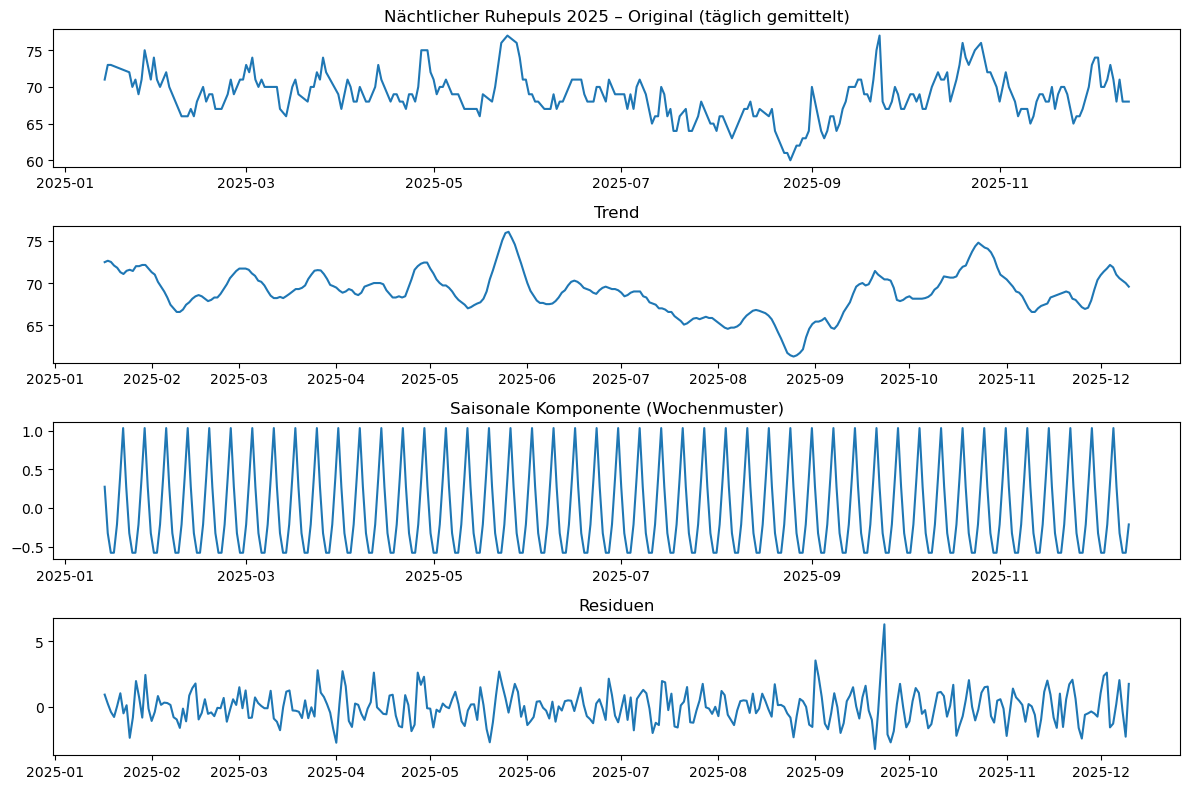

In [107]:
daily = df_2025.groupby("date", as_index=False)["resting_heart_rate"].mean()
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values("date")

ts = daily.set_index("date")["resting_heart_rate"]

full_index = pd.date_range(ts.index.min(), ts.index.max(), freq="D")
ts = ts.reindex(full_index)

ts = ts.interpolate(method="time")

decomp = seasonal_decompose(ts, model="additive", period=7)
trend = decomp.trend
seasonal = decomp.seasonal
resid = decomp.resid

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(ts)
plt.title("Nächtlicher Ruhepuls 2025 – Original (täglich gemittelt)")

plt.subplot(4, 1, 2)
plt.plot(trend)
plt.title("Trend")

plt.subplot(4, 1, 3)
plt.plot(seasonal)
plt.title("Saisonale Komponente (Wochenmuster)")

plt.subplot(4, 1, 4)
plt.plot(resid)
plt.title("Residuen")
plt.tight_layout()
plt.show()

Interpretation: Die Dekomposition zerlegt die Zeitreihe in vier Teile. Im ersten Plot sieht man den nächtlichen Ruhepuls mit den täglichen Schwankungen. Der Trend zeigt den groben Verlauf übers Jahr: Richtung Sommer wird der Ruhepuls tiefer (Tiefpunkt etwa August/September) und danach steigt er im Herbst wieder an. Die saisonale Komponente zeigt ein klares Wochenmuster (alle 7 Tage wiederholt sich das Muster), also dass gewisse Wochentage im Durchschnitt etwas höher oder tiefer sind. Die Residuen sind das, was nach Trend und Wochenmuster übrig bleibt – meistens nahe bei 0, aber mit einzelnen stärkeren Ausschlägen.


## 3.) Zeitreihen-Dekomposition mit Prophet

### In diesem Kapitel verwenden wir Prophet, um den nächtlichen Ruhepuls als Zeitreihe zu modellieren. Prophet zerlegt die Daten in einen langfristigen Trend und ein wiederkehrendes Wochenmuster und zeigt zusätzlich Unsicherheitsintervalle (wie sicher die Schätzung ist). Damit das Modell nicht jede kleine Schwankung “überlernt”, begrenzen wir die Anzahl der Trend-Wechselpunkte (Changepoints) auf 4. So fokussiert Prophet auf die grossen Veränderungen im Jahresverlauf.


In [109]:
train = ts.reset_index()
train.columns = ["ds", "y"]
train = train.dropna(subset=["y"]).sort_values("ds")

train["ds"] = pd.to_datetime(train["ds"])
if train["ds"].dt.tz is not None:
    train["ds"] = train["ds"].dt.tz_convert(None)

11:05:01 - cmdstanpy - INFO - Chain [1] start processing
11:05:01 - cmdstanpy - INFO - Chain [1] done processing


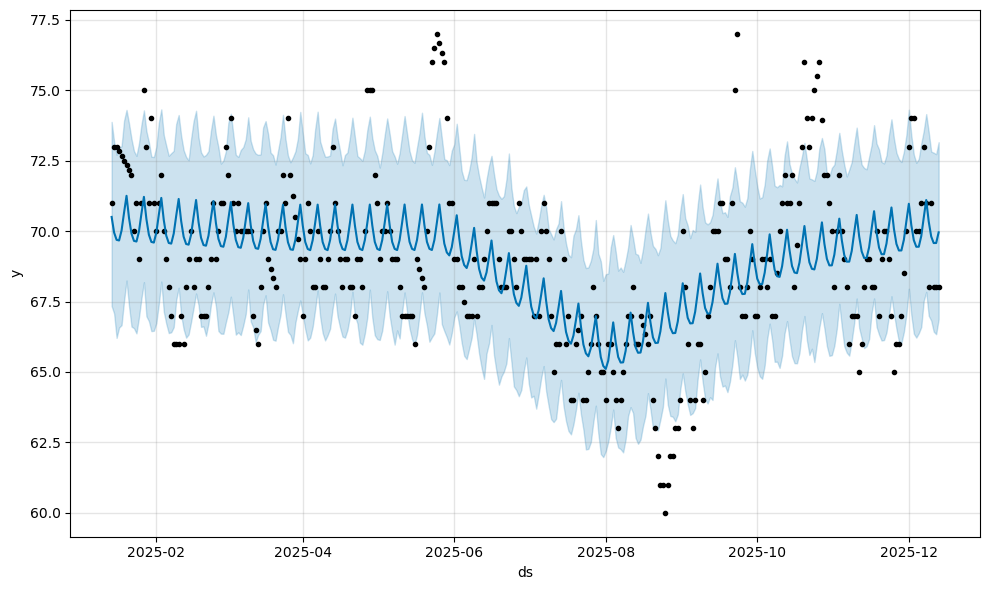

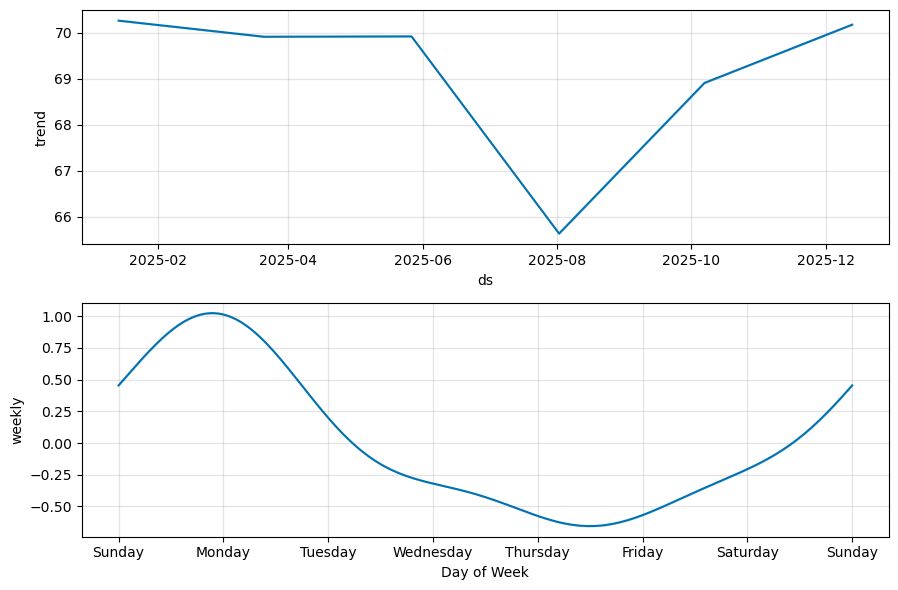

In [110]:
m = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality="auto",
    n_changepoints=4,
    interval_width=0.8,
    seasonality_mode="additive"
)

m.fit(train)
forecast = m.predict(train)

fig1 = m.plot(forecast)
fig2 = m.plot_components(forecast)
plt.show()

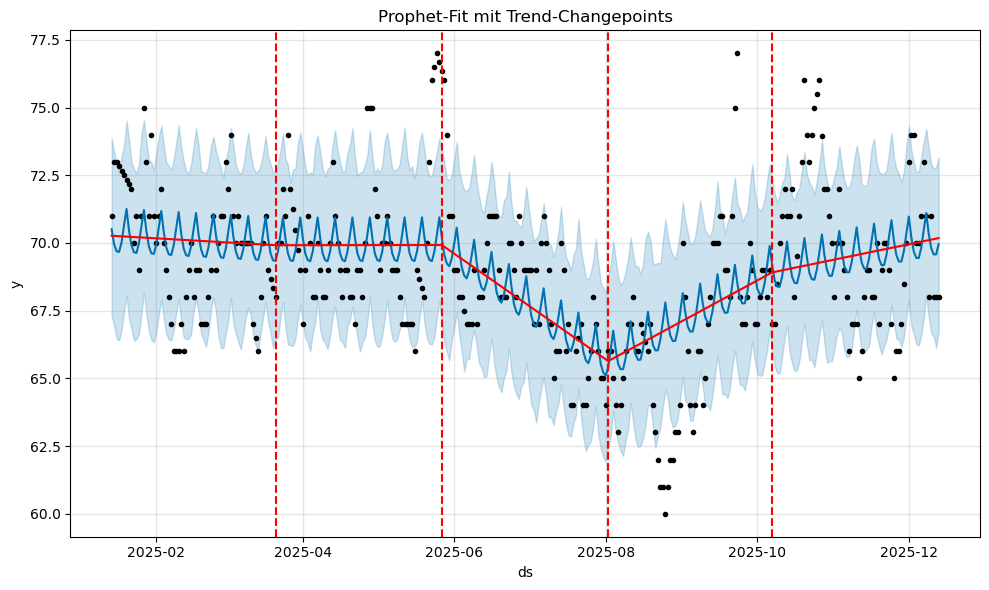

66    2025-03-20 23:00:00
133   2025-05-26 22:00:00
200   2025-08-01 22:00:00
266   2025-10-06 22:00:00
Name: ds, dtype: datetime64[ns]

In [166]:
train = train.copy()
train["ds"] = pd.to_datetime(train["ds"])
if getattr(train["ds"].dt, "tz", None) is not None:
    train["ds"] = train["ds"].dt.tz_localize(None)

m = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality="auto",
    n_changepoints=4,
    changepoint_prior_scale=0.05,  
    changepoint_range=0.8,         
    interval_width=0.8,
    seasonality_mode="additive"
)

m.fit(train)
forecast = m.predict(train)

fig = m.plot(forecast)
add_changepoints_to_plot(fig.gca(), m, forecast)
plt.title("Prophet-Fit mit Trend-Changepoints")
plt.tight_layout()
plt.show()

m.changepoints

Interpretation 1.Plot: Im ersten Prophet-Plot werden die echten Daten (schwarze Punkte) mit der Prophet-Schätzung verglichen (blaue Linie). Das hellblaue Band zeigt die Unsicherheit der Schätzung. Auffällig sind ein deutlicher Sommer-Tiefpunkt sowie einzelne Tage mit sehr hohen oder sehr tiefen Werten (Ausreisser), die nicht perfekt vom Modell erklärt werden.

2.Plot:Im zweiten Plot (Trend) sehen wir die langfristige Entwicklung ohne Wochentag-Schwankungen: Der Ruhepuls sinkt bis etwa Juli/August deutlich (Sommer-Tiefpunkt) und steigt danach Richtung Herbst/Winter wieder an.

3.Plot: Im dritten Plot (Weekly) sieht man den durchschnittlichen Effekt der Wochentage: Am Montag ist der Ruhepuls im Mittel am höchsten, gegen Ende der Woche (Donnerstag/Freitag) am tiefsten. Der Unterschied beträgt ungefähr rund 1 bpm zwischen dem höchsten und tiefsten Tag.

4.Plot: Im vierten Plot sieht man, wo Prophet Trendwechsel setzt: die roten gestrichelten Linien markieren Zeitpunkte, an denen der Trend „abknicken“ darf. Hier passiert das etwa Ende März, Ende Mai, Anfang August und Anfang Oktober. Man erkennt dabei: Richtung Sommer geht der Trend runter (Tiefpunkt um Anfang August) und danach im Herbst/Winter wieder hoch.

### In diesem Schritt trainieren wir ein Prophet-Modell auf der täglichen Ruhepuls-Zeitreihe und prüfen die Vorhersagequalität mit Cross-Validation. Dabei wird das Modell wiederholt auf einem Startfenster (initial) trainiert und jeweils eine 30-Tage-Prognose (horizon) bewertet. Wir starten mit einem 80%-Unsicherheitsintervall, um zu sehen, wie gut die Intervalle die echten Werte abdecken (coverage).


  0%|          | 0/9 [00:00<?, ?it/s]

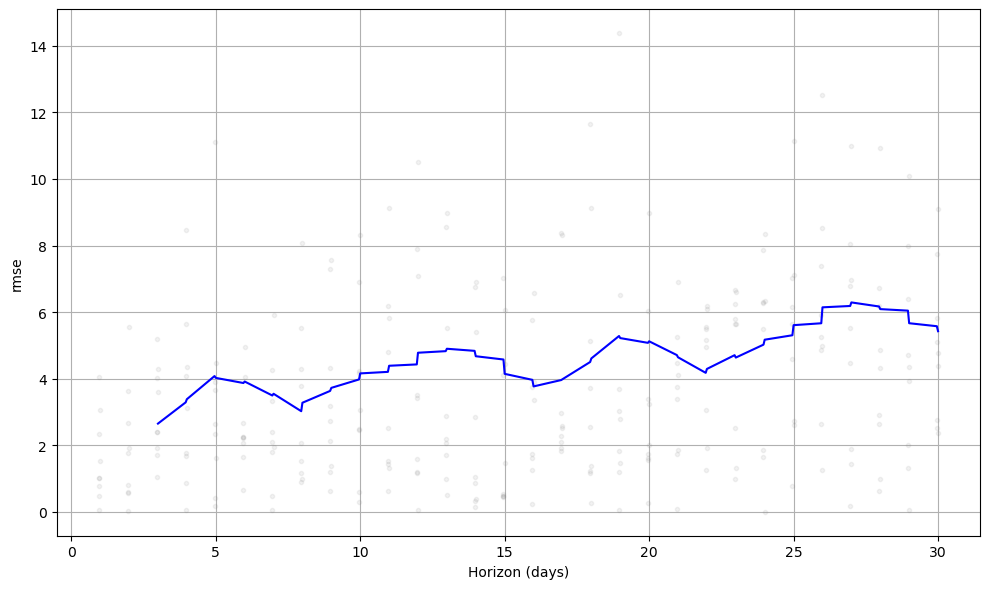

,horizon,mae,rmse,mape,coverage
0,30 days,3.701183,4.63603,0.053995,0.514815


In [122]:
warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("cmdstanpy").setLevel(logging.CRITICAL)
logging.getLogger("prophet").setLevel(logging.CRITICAL)

train = ts.reset_index()
train.columns = ["ds", "y"]
train = train.dropna(subset=["y"]).sort_values("ds")
train["ds"] = pd.to_datetime(train["ds"])
if train["ds"].dt.tz is not None:
    train["ds"] = train["ds"].dt.tz_convert(None)

m = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality="auto",
    n_changepoints=4,
    interval_width=0.8,
    seasonality_mode="additive"
)
m.fit(train)

df_cv = cross_validation(
    m,
    initial="180 days",
    period="14 days",
    horizon="30 days"
)

plot_cross_validation_metric(df_cv, metric="rmse")
plt.tight_layout()
plt.show()

df_p = performance_metrics(df_cv, rolling_window=1)
df_p[["horizon", "mae", "rmse", "mape", "coverage"]].head()

Interpretation: Die Cross-Validation mit einem Vorhersagehorizont von 30 Tagen zeigt, dass Prophet im Schnitt um etwa MAE ≈ 3.7 bpm danebenliegt (RMSE ≈ 4.6 bpm). Das heisst: Die Prognose weicht typischerweise um ein paar bpm vom echten Ruhepuls ab. Der relative Fehler liegt bei MAPE ≈ 5.4%. 

Auffällig ist die Coverage von nur ≈ 0.51: Obwohl wir ein 80%-Unsicherheitsintervall (interval_width = 0.8) eingestellt haben, liegen nur rund 51% der echten Werte innerhalb des Bandes. Das Unsicherheitsband ist also zu eng und Prophet unterschätzt die Unsicherheit. Im nächsten Schritt erhöhen wir das Intervall (z.B. auf 95%) und prüfen, ob die Coverage näher an den Zielwert kommt.


  0%|          | 0/9 [00:00<?, ?it/s]

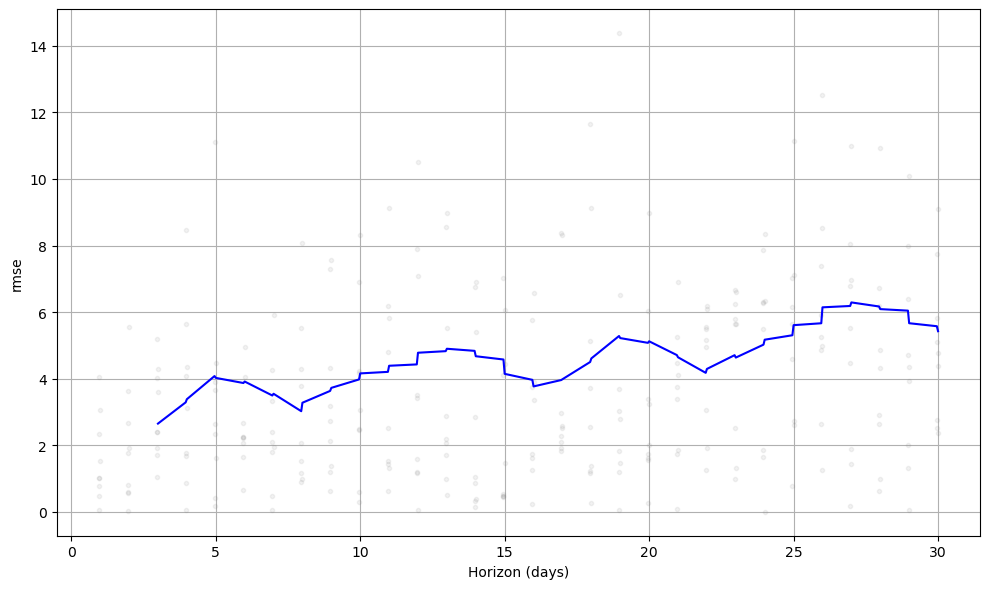

,horizon,mae,rmse,mape,coverage
0,30 days,3.701183,4.63603,0.053995,0.67037


In [123]:
m2 = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality="auto",
    n_changepoints=4,
    interval_width=0.95,
    seasonality_mode="additive"
)
m2.fit(train)

df_cv2 = cross_validation(
    m2,
    initial="180 days",
    period="14 days",
    horizon="30 days"
)
plot_cross_validation_metric(df_cv2, metric="rmse")
plt.tight_layout()
plt.show()

df_p2 = performance_metrics(df_cv2, rolling_window=1)
df_p2[["horizon", "mae", "rmse", "mape", "coverage"]].head()

Interpretation: Prophet unterschätzt die Unsicherheit die Daten weiterhin. Es gibt zusätzliche Einflüsse (Ausreisser / spezielle Tage / Abhängigkeit von Tag zu Tag), die im Modell noch nicht erklärt sind.

### Als nächstes prüfen wir die Residuen. Damit sehen wir, ob nach Trend und Wochenmuster noch ein Muster übrig bleibt. Mit der ACF (Autokorrelation) testen wir, ob Residuen von aufeinanderfolgenden Tagen voneinander abhängig sind. Residuum = echter Wert − Prophet-Schätzung

In [124]:
tmp = train.merge(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds", how="left")
tmp["resid"] = tmp["y"] - tmp["yhat"]

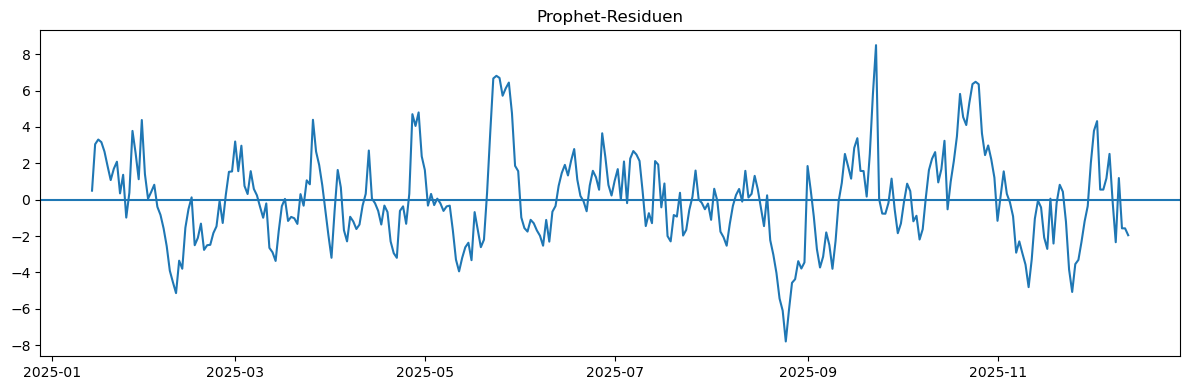

In [125]:
plt.figure(figsize=(12, 4))
plt.plot(tmp["ds"], tmp["resid"])
plt.axhline(0)
plt.title("Prophet-Residuen")
plt.tight_layout()
plt.show()

Interpretation: Die Residuen schwanken um 0 und wirken grösstenteils zufällig, was zeigt, dass Prophet Trend und Wochenmuster gut entfernt. Allerdings gibt es einzelne starke Ausreisser und Phasen mit mehreren Tagen ähnlicher Abweichung, was auf zusätzliche Einflüsse bzw. Abhängigkeiten zwischen Tagen hindeutet.


In [127]:
tmp["resid"].describe()

count    334.000000
mean       0.000039
std        2.479822
min       -7.801201
25%       -1.605682
50%       -0.130157
75%        1.549249
max        8.503173
Name: resid, dtype: float64

Interpretation: Der Mittelwert der Residuen liegt mit mean ≈ 0.00004 praktisch bei 0. Das heisst, Prophet hat keinen systematischen Bias und liegt im Durchschnitt weder zu hoch noch zu tief. Die typische Abweichung liegt bei std ≈ 2.48 bpm, also weicht die Schätzung an einem “normalen” Tag oft um ca. 2–3 bpm ab. 

Die mittleren 50% der Residuen liegen ungefähr zwischen −1.61 bpm (25%) und +1.55 bpm (75%); der Median ist leicht negativ (50% ≈ −0.13 bpm), also minimal eher eine ganz kleine Überschätzung, aber praktisch vernachlässigbar. Die Extremwerte reichen von −7.8 bis +8.5 bpm, das sind einzelne Tage, an denen das Modell deutlich daneben liegt.

### Als nächstes prüfen wir mit der Autokorrelationsfunktion (ACF), ob die Residuen wirklich zufällig sind. Wenn die Residuen unabhängig wären, sollten die Korrelationen für die ersten Lags (z.B. 1–7 Tage) nahe bei 0 liegen. Deutliche Ausschläge bedeuten, dass aufeinanderfolgende Tage noch zusammenhängen.


<Figure size 1000x400 with 0 Axes>

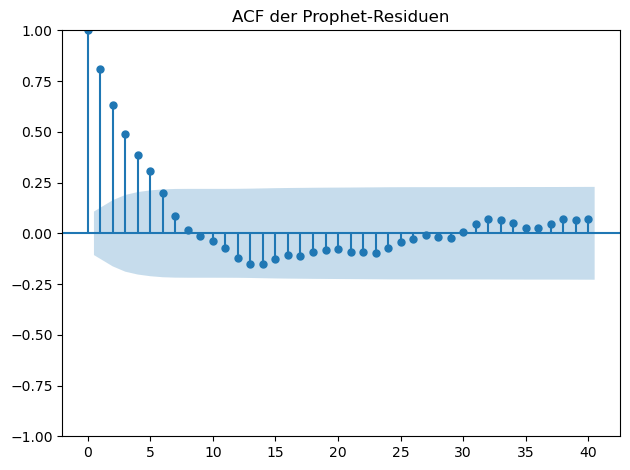

In [56]:
plt.figure(figsize=(10, 4))
plot_acf(tmp["resid"].dropna(), lags=40)
plt.title("ACF der Prophet-Residuen")
plt.tight_layout()
plt.show()

Interpretation: Die ACF der Prophet-Residuen zeigt bei kleinen Lags (ca. 1–6 Tage) klare positive Autokorrelation (mehrere Balken ausserhalb des blauen Bands). Das bedeutet: Abweichungen sind nicht zufällig, sondern halten oft mehrere Tage an. Ab etwa einer Woche werden die Korrelationen deutlich kleiner und liegen meist im Konfidenzband. Insgesamt sind die Residuen damit nicht unabhängig. Trend und Wochenmuster erklären nicht alles.

### Jetzt definieren wir wichtige Zeiträume (Semesterferien, Prüfungssession, Studienreise und Krankheit) als 0/1-Variablen. Für jeden Zeitraum erstellen wir eine neue Spalte und setzen sie auf 1, wenn das Datum `ds` innerhalb des entsprechenden Intervalls liegt. So können wir später prüfen, ob diese Phasen die Residuen (y − yhat) zusätzlich erklären.

In [131]:
event_periods = {
    "semesterferien": [("2025-06-22", "2025-09-07")],
    "pruefungssession": [("2025-05-24", "2025-06-21")],
    "studienreise": [("2025-05-19", "2025-05-23")],
    "krankheit": [("2025-09-21", "2025-09-25")],
}

for ev in event_periods:
    tmp[ev] = 0
    for start, end in event_periods[ev]:
        start = pd.to_datetime(start)
        end = pd.to_datetime(end)
        tmp.loc[(tmp["ds"] >= start) & (tmp["ds"] <= end), ev] = 1

### Als nächstes erklären wir die Prophet-Residuen mit den Event-Dummies. Zusätzlich nehmen wir das Residuum vom Vortag (Lag-1) auf, weil die ACF eine Abhängigkeit zwischen aufeinanderfolgenden Tagen gezeigt hat.


In [132]:
tmp["resid_lag1"] = tmp["resid"].shift(1)

X = tmp[["resid_lag1"] + list(event_periods.keys())]
X = sm.add_constant(X, has_constant="add")
y = tmp["resid"]

model = sm.OLS(y, X, missing="drop").fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  resid   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.9
Date:                Sun, 18 Jan 2026   Prob (F-statistic):           1.81e-75
Time:                        12:13:03   Log-Likelihood:                -592.76
No. Observations:                 333   AIC:                             1198.
Df Residuals:                     327   BIC:                             1220.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0002      0.098  

Interpretation: Das Modell erklärt rund 66.5% der Schwankungen in den Residuen (R² = 0.665). Der mit Abstand wichtigste Faktor ist das Residuum vom Vortag: resid_lag1 hat einen klar positiven Effekt (coef = 0.807, p < 0.001). Das bedeutet: Wenn der Ruhepuls an einem Tag höher/tiefer als von Prophet erwartet ist, bleibt diese Abweichung am nächsten Tag oft zu einem grossen Teil bestehen.

In [134]:
result = pd.DataFrame({
    "coef": model.params,
    "pvalue": model.pvalues
}).sort_values("pvalue")

result

,coef,pvalue
resid_lag1,0.807086,3.753308e-75
studienreise,2.281681,1.950524e-03
semesterferien,-0.142645,4.604492e-01
pruefungssession,-0.009902,9.730928e-01
krankheit,-0.004904,9.947439e-01
const,0.000245,9.979992e-01


Interpretation: 

- resid_lag1 (coef = 0.81, p ≈ 3.8e−75): Sehr starker und klarer Effekt. Wenn der Ruhepuls an einem Tag höher/tiefer ist als Prophet erwartet, bleibt diese Abweichung am nächsten Tag oft ähnlich (ca. 80% “nimmt er mit”). Mögliche Ursache: Erholung/Belastung wirkt über mehrere Tage (z.B. Training, Stress, Schlafdefizit, beginnende Erkältung), daher ist der Ruhepuls nicht unabhängig von Tag zu Tag.

- studienreise (coef = +2.28, p = 0.002): In der Studienreise ist der Ruhepuls im Schnitt ca. 2.3 bpm höher als Prophet erwartet. Mögliche Ursache war sicher: mehr Alkohol, weniger Schlaf, mehr Aktivität/Belastung und ungewohnte Tagesstruktur → höhere “Stress-/Erholungs”-Belastung und damit höherer Ruhepuls.

- semesterferien (coef = −0.14, p = 0.46): Kleiner negativer Effekt, aber nicht signifikant. Das heisst: In den Semesterferien ist der Ruhepuls nicht zuverlässig anders als sonst, nachdem Trend/Wochentage schon durch Prophet entfernt wurden. Mögliche Ursache: Ferien-Effekt ist individuell/uneinheitlich (mal mehr Erholung, mal Reisen/Feiern) und gleicht sich im Mittel aus.

- pruefungssession (coef = −0.01, p = 0.97): Praktisch kein Effekt. Das spricht dafür, dass die Prüfungssession in diesen Daten keinen zusätzlichen, stabilen Einfluss auf die Abweichungen hat. Mögliche Ursache: Stress ist nicht konstant über alle Prüfungstage oder wird von anderen Faktoren überlagert.

- krankheit (coef = −0.00, p = 0.995): Kein messbarer Effekt in diesem Modell. Wahrscheinlich ist das Zeitfenster zu kurz / zu wenige Tage, oder die “Krankheit” war physiologisch nicht stark genug, um als klarer Zusatz-Effekt sichtbar zu werden.).

- const (coef ≈ 0.00, p ≈ 0.998): Der Basiswert der Residuen ist praktisch 0. Das ist gut: Prophet hat im Mittel keinen systematischen Fehler (keine dauerhafte Über- oder Unterschätzung).

### Jetzt testen wir, ob bekannte Ereignisse (Semesterferien, Prüfungssession, Studienreise, Krankheit) die Prognose verbessern. Dafür bauen wir diese Zeiträume als „holidays“ in Prophet ein und vergleichen die Cross-Validation-Kennzahlen mit dem Basismodell. So sehen wir, ob die Vorhersage genauer wird und ob die Unsicherheitsbänder realistischer sind (Coverage).



In [143]:
holidays = []
for name, periods in event_periods.items():
    for start, end in periods:
        dates = pd.date_range(pd.to_datetime(start), pd.to_datetime(end), freq="D")
        holidays.append(pd.DataFrame({"holiday": name, "ds": dates}))
holidays = pd.concat(holidays, ignore_index=True)

m_h = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality="auto",
    n_changepoints=4,
    interval_width=0.95,
    seasonality_mode="additive",
    holidays=holidays
)

m_h.fit(train)

df_cv_h = cross_validation(m_h, initial="180 days", period="14 days", horizon="30 days")
df_p_h = performance_metrics(df_cv_h, rolling_window=1)

df_p_h[["horizon", "mae", "rmse", "mape", "coverage"]].head()

  0%|          | 0/9 [00:00<?, ?it/s]

,horizon,mae,rmse,mape,coverage
0,30 days,4.163804,5.307475,0.060449,0.611111


Interpretation: Mit Events als „holidays“ wird die Prognose nicht genauer (Fehlerwerte steigen). Dafür steigt die Coverage von ca. 0.51 auf ca. 0.61: Die Unsicherheitsbänder treffen die echten Werte häufiger. Insgesamt macht das Holiday-Modell die Unsicherheit etwas realistischer, aber es verbessert die Vorhersagequalität nicht.

### Im nächsten Schritt prüfen wir, ob die höhere Coverage beim Holiday-Modell wirklich durch die Events entsteht oder einfach nur daher kommt, dass wir ein breiteres Unsicherheitsintervall (interval_width=0.95) verwenden. Dazu vergleichen wir (1) das Basismodell mit interval_width=0.95 ohne Events und (2) das Event/Holiday-Modell mit interval_width=0.95. So sehen wir, ob die Events zusätzlich einen Nutzen bringen.


In [147]:
warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("cmdstanpy").setLevel(logging.CRITICAL)
logging.getLogger("prophet").setLevel(logging.CRITICAL)

m_base95 = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality="auto",
    n_changepoints=4,
    interval_width=0.95,
    seasonality_mode="additive"
)
m_base95.fit(train)

df_cv_base95 = cross_validation(
    m_base95,
    initial="180 days",
    period="14 days",
    horizon="30 days"
)
df_p_base95 = performance_metrics(df_cv_base95, rolling_window=1)

base95_row = df_p_base95[["horizon","mae","rmse","mape","coverage"]].head(1)
display(base95_row)

holidays = []
for name, periods in event_periods.items():
    for start, end in periods:
        dates = pd.date_range(pd.to_datetime(start), pd.to_datetime(end), freq="D")
        holidays.append(pd.DataFrame({"holiday": name, "ds": dates}))
holidays = pd.concat(holidays, ignore_index=True)

m_h95 = Prophet(
    weekly_seasonality=True,
    daily_seasonality=False,
    yearly_seasonality="auto",
    n_changepoints=4,
    interval_width=0.95,
    seasonality_mode="additive",
    holidays=holidays
)
m_h95.fit(train)

df_cv_h95 = cross_validation(
    m_h95,
    initial="180 days",
    period="14 days",
    horizon="30 days"
)
df_p_h95 = performance_metrics(df_cv_h95, rolling_window=1)

hol95_row = df_p_h95[["horizon","mae","rmse","mape","coverage"]].head(1)
display(hol95_row)

compare = pd.concat(
    [base95_row.assign(model="Baseline (95%)"),
     hol95_row.assign(model="Events/Holidays (95%)")],
    ignore_index=True
)[["model","horizon","mae","rmse","mape","coverage"]]

display(compare)

  0%|          | 0/9 [00:00<?, ?it/s]

,horizon,mae,rmse,mape,coverage
0,30 days,3.701183,4.63603,0.053995,0.67037


  0%|          | 0/9 [00:00<?, ?it/s]

,horizon,mae,rmse,mape,coverage
0,30 days,4.163804,5.307475,0.060449,0.611111


,model,horizon,mae,rmse,mape,coverage
0,Baseline (95%),30 days,3.701183,4.636030,0.053995,0.670370
1,Events/Holidays (95%),30 days,4.163804,5.307475,0.060449,0.611111


Interpretation: Das Basismodell (95%-Intervall) hat einen durchschnittlichen Fehler von MAE ≈ 3.70 bpm und RMSE ≈ 4.64 bpm. Das heisst: Die Vorhersage liegt im Schnitt etwa 3–5 bpm neben dem echten Wert. Der relative Fehler liegt bei MAPE ≈ 5.4%. Die Coverage ist ≈ 0.67, also liegen rund 67% der echten Werte im 95%-Unsicherheitsband (das Band ist damit eher zu eng).

Beim Modell mit Events/Holidays wird es nicht besser: Die Fehler sind höher (MAE ≈ 4.16 bpm, RMSE ≈ 5.31 bpm, MAPE ≈ 6.0%) und die Coverage sinkt auf ≈ 0.61. In diesem Setup bringen die Events als Prophet-“holidays” keine Verbesserung, sondern machen die Prognose eher schlechter.

## 4.) Zusatzanalyse: Regelbasierter Kalender für Arbeit/Schule/Frei


### Da ich im Jahr 2025 einen Arbeitsvertrag über 50% hatte, aber effektiv etwas mehr gearbeitet habe (ca. 55%), habe ich für die Zusatzanalyse einen vereinfachten Tagesplan erstellt. Dabei habe ich jedem Datum eine Kategorie zugewiesen: Arbeit (1), Schule (2) oder Frei/Ferien/Wochenende (3). Anstatt einen detaillierten Dienstplan pro Tag zu verwenden, habe ich die Einteilung regelbasiert über Wochentage und drei Zeitabschnitte abgebildet (bis 16.05., Sommerphase, ab 01.09.). Definierte Ferienzeiträume haben diese Regeln überschrieben und wurden immer als frei markiert. Wichtig: Diese Einteilung ist kein akkurates Abbild meines tatsächlichen Alltags, sondern eine grobe Annäherung, um einen möglichen Unterschied zwischen Arbeits- und Studientagen in den Daten explorativ zu prüfen.

In [155]:
start = train["ds"].min()
end = train["ds"].max()

plan = pd.DataFrame({"ds": pd.date_range(start, end, freq="D")})
plan["weekday"] = plan["ds"].dt.weekday
plan["status"] = 3

cut1_end = pd.to_datetime("2025-05-16")
cut2_start = pd.to_datetime("2025-09-01")

is_weekday = plan["weekday"] <= 4

work_days_1 = {0, 1, 2}
school_days_1 = {3, 4}

work_days_summer = {0, 1, 2, 3, 4}

work_days_2 = {0, 1, 4}
school_days_2 = {2, 3}

mask1 = (plan["ds"] <= cut1_end) & is_weekday
plan.loc[mask1 & plan["weekday"].isin(work_days_1), "status"] = 1
plan.loc[mask1 & plan["weekday"].isin(school_days_1), "status"] = 2

mask_summer = (plan["ds"] > cut1_end) & (plan["ds"] < cut2_start) & is_weekday
plan.loc[mask_summer & plan["weekday"].isin(work_days_summer), "status"] = 1

mask2 = (plan["ds"] >= cut2_start) & is_weekday
plan.loc[mask2 & plan["weekday"].isin(work_days_2), "status"] = 1
plan.loc[mask2 & plan["weekday"].isin(school_days_2), "status"] = 2

ferien = [
    ("2025-02-03", "2025-02-14"),
    ("2025-07-21", "2025-08-08"),
]
for a, b in ferien:
    a = pd.to_datetime(a)
    b = pd.to_datetime(b)
    plan.loc[(plan["ds"] >= a) & (plan["ds"] <= b), "status"] = 3

plan = plan[["ds", "status"]]

counts = plan["status"].value_counts().sort_index()
labels = {
    1: "Arbeitstage",
    2: "Schultage",
    3: "Frei/Ferien/Wochenende"
}
pretty = counts.rename(index=labels).to_frame(name="Anzahl Tage")
pretty

,Anzahl Tage
status,
Arbeitstage,155
Schultage,62
Frei/Ferien/Wochenende,117


In [156]:
print("Start:", plan["ds"].min())
print("Ende :", plan["ds"].max())
print("Tage :", len(plan))

Start: 2025-01-13 23:00:00
Ende : 2025-12-12 23:00:00
Tage : 334


### Als nächstes verknüpfen wir den generierten Tagesplan (Arbeit/Schule/Frei) mit den Prophet-Residuen. Danach testen wir mit einer Regression, ob Arbeitstage oder Schultage die Abweichungen (y − yhat) zusätzlich erklären. Frei/Ferien dient dabei als Referenz. Zusätzlich nehmen wir resid_lag1 auf, weil die ACF eine Tages-Abhängigkeit gezeigt hat.


In [159]:
tmp2 = tmp.copy()
tmp2["ds"] = pd.to_datetime(tmp2["ds"])

plan2 = plan.copy()
plan2["ds"] = pd.to_datetime(plan2["ds"])

tmp2 = tmp2.merge(plan2, on="ds", how="left")

tmp2["ist_arbeitstag"] = (tmp2["status"] == 1).astype(int)
tmp2["ist_schultag"] = (tmp2["status"] == 2).astype(int)

tmp2["resid_lag1"] = tmp2["resid"].shift(1)

X = tmp2[["resid_lag1", "ist_arbeitstag", "ist_schultag"]]
X = sm.add_constant(X, has_constant="add")
y = tmp2["resid"]

model_plan_simple = sm.OLS(y, X, missing="drop").fit()
print(model_plan_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                  resid   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     208.1
Date:                Sun, 18 Jan 2026   Prob (F-statistic):           1.17e-75
Time:                        13:19:29   Log-Likelihood:                -597.78
No. Observations:                 333   AIC:                             1204.
Df Residuals:                     329   BIC:                             1219.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0095      0.092      0.

Interpretation: Das vereinfachte Modell (nur Arbeit/Schule/Frei + Lag-1) erklärt rund 65.5% der Schwankungen in den Residuen (R² = 0.655). Der klar wichtigste Effekt ist wieder die Tages-Abhängigkeit: Das Residuum vom Vortag (resid_lag1) ist sehr stark und hoch signifikant (coef = 0.81, p < 0.001). Das bedeutet: Wenn der Ruhepuls an einem Tag höher oder tiefer als erwartet ist, bleibt diese Abweichung am nächsten Tag oft zu einem grossen Teil bestehen.

Arbeitstage zeigen praktisch keinen zusätzlichen Effekt gegenüber Frei-Tagen (ist_arbeitstag: coef = +0.03 bpm, p = 0.881). Auch Schultage unterscheiden sich nicht klar von Frei-Tagen (ist_schultag: coef = −0.21 bpm, p = 0.444). In diesen Daten gibt es damit keinen stabilen Hinweis, dass „Arbeit vs. Schule vs. frei“ die Abweichungen vom Prophet-Modell zusätzlich erklärt – die Restschwankungen werden vor allem durch die Abhängigkeit von Tag zu Tag bestimmt.

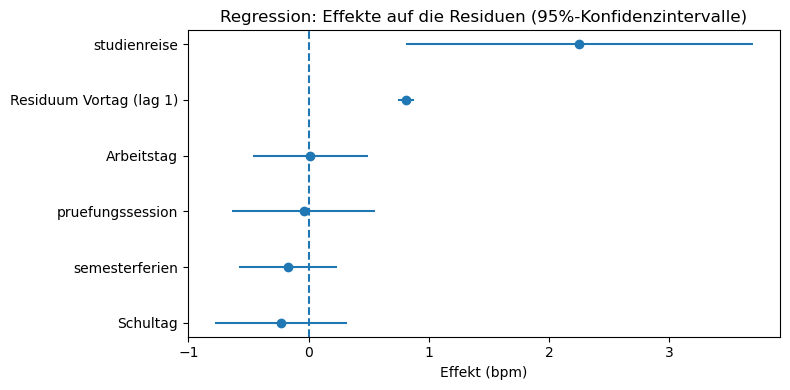

In [162]:
df_plot = pd.DataFrame({
    "term": model_plan.params.index,
    "coef": model_plan.params.values,
    "low": model_plan.conf_int()[0].values,
    "high": model_plan.conf_int()[1].values,
    "pvalue": model_plan.pvalues.values
})

df_plot = df_plot[df_plot["term"] != "const"].copy()

# (optional) schönere Labels
label_map = {
    "resid_lag1": "Residuum Vortag (lag 1)",
    "ist_arbeitstag": "Arbeitstag",
    "ist_schultag": "Schultag",
}
df_plot["term"] = df_plot["term"].replace(label_map)

# Sortieren nach Effekt
df_plot = df_plot.sort_values("coef")

plt.figure(figsize=(8, 4))
plt.errorbar(
    df_plot["coef"], df_plot["term"],
    xerr=[df_plot["coef"] - df_plot["low"], df_plot["high"] - df_plot["coef"]],
    fmt="o"
)
plt.axvline(0, linestyle="--")
plt.title("Regression: Effekte auf die Residuen (95%-Konfidenzintervalle)")
plt.xlabel("Effekt (bpm)")
plt.ylabel("")
plt.tight_layout()
plt.show()

Interpretation:

Die Studienreise hat einen klar positiven Effekt (Intervall liegt vollständig über 0) → in dieser Zeit war der Ruhepuls höher als vom Prophet-Modell erwartet.

Das Residuum vom Vortag (lag 1) ist ebenfalls klar positiv → Abweichungen “halten” oft über mehrere Tage an (Autokorrelation).

Arbeitstag, Schultag, Prüfungssession, Semesterferien liegen mit ihren Intervallen um 0 → kein eindeutiger zusätzlicher Effekt auf die Abweichungen im Vergleich zur Referenz.

## 5.) Schlusszusammenfassung

Ziel dieser Arbeit war zu untersuchen, wie sich mein **nächtlicher Ruhepuls** im Jahr **2025** verändert und ob es **Trend**, **Wochenmuster** und **Autokorrelation** zwischen aufeinanderfolgenden Nächten gibt. Als Datengrundlage dienten persönliche **Fitbit-Schlafdaten**, aufbereitet als **tägliche Zeitreihe** (eine Beobachtung pro Nacht).

Die deskriptiven Plots (Zeitreihe, Monatsmittel, Boxplots nach Wochentag) sowie die Zeitreihen-Dekomposition zeigen einen **klaren Jahresverlauf**: Der Ruhepuls sinkt im Verlauf Richtung **Sommer** (Tiefpunkt etwa **August/September**) und steigt danach im **Herbst/Winter** wieder an. Zusätzlich ist ein **Wochenmuster** erkennbar: Bestimmte **Wochentage** liegen im Mittel leicht höher oder tiefer als andere.

Auch die Abhängigkeit von Nacht zu Nacht ist deutlich: Die **ACF der Prophet-Residuen** zeigt eine **positive Autokorrelation** bei kleinen Lags (mehrere Tage). Das bedeutet: Wenn der Ruhepuls an einem Tag höher oder tiefer als erwartet ist, bleibt diese Abweichung oft **für einige Tage** bestehen. Die Residuen sind damit **nicht reines Zufallsrauschen**, sondern enthalten noch **zeitliche Abhängigkeit**, die Prophet mit Trend und Wochenmuster allein nicht vollständig erklärt.

**Fazit zu den Hypothesen:**
- **H0 (kein Trend und keine Autokorrelation):** In dieser **explorativen Analyse** finden wir **keine Unterstützung für H0**. Stattdessen zeigen die Ergebnisse einen **Trend** über das Jahr und eine klare **Autokorrelation** zwischen aufeinanderfolgenden Nächten.
- **H1 (systematischer Trend und/oder wiederkehrende Muster):** **H1 wird unterstützt**, da ein **Jahrestrend**, ein **Wochenrhythmus** und eine **Tages-Abhängigkeit** (Autokorrelation) in den Daten sichtbar sind.

# Ende 